## Setup and preprocessing — DDD, fresh raw load

In [2]:
import pandas as pd
import numpy as np
import os
import networkx as nx
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder
from dowhy import CausalModel
from econml.dml import CausalForestDML

OUTPUT_DIR = r"C:\Users\Disha Sharma\Desktop\Paper_1\RQ2\DDD"
os.makedirs(OUTPUT_DIR, exist_ok=True)

DATA_PATH = r"C:\Users\Disha Sharma\Desktop\Paper_1\ModuleWise\DDD.csv"
df = pd.read_csv(DATA_PATH)

df_sel = df.copy()

df_sel['imd_band'] = df_sel['imd_band'].replace('10-20', '10-20%')
imd_mode = df_sel['imd_band'].mode()[0]
df_sel['imd_band'] = df_sel['imd_band'].fillna(imd_mode)

final_result_map = {'Withdrawn': 0, 'Fail': 1, 'Pass': 2, 'Distinction': 3}
df_sel['final_result'] = df_sel['final_result'].map(final_result_map)

highest_education_map = {
    'No Formal quals': 0, 'Lower Than A Level': 1, 'A Level or Equivalent': 2,
    'HE Qualification': 3, 'Post Graduate Qualification': 4
}
df_sel['highest_education'] = df_sel['highest_education'].map(highest_education_map)

imd_band_map = {
    '0-10%': 0, '10-20%': 1, '20-30%': 2, '30-40%': 3, '40-50%': 4,
    '50-60%': 5, '60-70%': 6, '70-80%': 7, '80-90%': 8, '90-100%': 9
}
df_sel['imd_band'] = df_sel['imd_band'].map(imd_band_map)

age_band_map = {'0-35': 0, '35-55': 1, '55<=': 2}
df_sel['age_band'] = df_sel['age_band'].map(age_band_map)

df_sel['gender'] = df_sel['gender'].map({'F': 0, 'M': 1})
df_sel['disability'] = df_sel['disability'].map({'N': 0, 'Y': 1})

le = LabelEncoder()
df_sel['region'] = le.fit_transform(df_sel['region'])

assessment_cols = [c for c in df_sel.columns if c.startswith('ass_') and c.endswith('_score')]
for col in assessment_cols:
    df_sel[col] = df_sel[col].fillna(-1)
    try:
        df_sel[col] = pd.qcut(df_sel[col], q=4, labels=False, duplicates='drop')
    except ValueError:
        pass

click_cols = [c for c in df_sel.columns if c.startswith('clicks_')]
for col in click_cols:
    df_sel[col] = df_sel[col].fillna(0)

print(df_sel.shape)
print("Assessment columns:", assessment_cols)
print("Click columns:", click_cols)
df_sel.isna().sum().sum()

(4969, 37)
Assessment columns: ['ass_1_score', 'ass_2_score', 'ass_3_score', 'ass_4_score', 'ass_5_score', 'ass_6_score', 'ass_7_score']
Click columns: ['clicks_externalquiz', 'clicks_forumng', 'clicks_glossary', 'clicks_homepage', 'clicks_oucollaborate', 'clicks_oucontent', 'clicks_ouwiki', 'clicks_resource', 'clicks_subpage', 'clicks_url']


np.int64(17468)

## Click variation check, total_clicks composite, quartile binning

In [7]:
for col in click_cols:
    print(col, "nonzero:", (df_sel[col] > 0).sum(), "| unique vals:", df_sel[col].nunique())

clicks_externalquiz nonzero: 3779 | unique vals: 86
clicks_forumng nonzero: 4019 | unique vals: 945
clicks_glossary nonzero: 1460 | unique vals: 162
clicks_homepage nonzero: 4527 | unique vals: 834
clicks_oucollaborate nonzero: 3073 | unique vals: 133
clicks_oucontent nonzero: 4404 | unique vals: 504
clicks_ouwiki nonzero: 2369 | unique vals: 292
clicks_resource nonzero: 4302 | unique vals: 261
clicks_subpage nonzero: 4407 | unique vals: 655
clicks_url nonzero: 4003 | unique vals: 173


## total_clicks composite — sum raw clicks, quartile-bin, drop individual columns

In [10]:
df_sel['total_clicks'] = df_sel[click_cols].sum(axis=1)
df_sel['total_clicks'] = pd.qcut(df_sel['total_clicks'], q=4, labels=False, duplicates='drop')

print(df_sel['total_clicks'].nunique(), "bins")
print(df_sel['total_clicks'].value_counts().sort_index())

df_sel_combined = df_sel.drop(columns=click_cols)
print(df_sel_combined.shape)

4 bins
total_clicks
0    1244
1    1242
2    1241
3    1242
Name: count, dtype: int64
(4969, 28)


## Final modeling variable set — drop identifiers and date columns

In [13]:
date_cols = [c for c in df_sel_combined.columns if c.endswith('_date')] + ['date_registration', 'date_unregistration']
id_cols = ['code_presentation', 'id_student']

df_model = df_sel_combined.drop(columns=date_cols + id_cols)

print(df_model.shape)
df_model.columns.tolist()

(4969, 17)


['gender',
 'region',
 'highest_education',
 'imd_band',
 'age_band',
 'num_of_prev_attempts',
 'studied_credits',
 'disability',
 'final_result',
 'ass_1_score',
 'ass_2_score',
 'ass_3_score',
 'ass_4_score',
 'ass_5_score',
 'ass_6_score',
 'ass_7_score',
 'total_clicks']

## Build DDD combined DAG in networkx, derive adjustment sets

In [18]:
edges = [
    ('gender', 'age_band'),
    ('gender', 'studied_credits'),
    ('gender', 'disability'),
    ('gender', 'total_clicks'),
    ('highest_education', 'region'),
    ('imd_band', 'region'),
    ('disability', 'region'),
    ('age_band', 'highest_education'),
    ('highest_education', 'disability'),
    ('age_band', 'total_clicks'),
    ('num_of_prev_attempts', 'total_clicks'),
    ('ass_1_score', 'ass_2_score'),
    ('ass_1_score', 'ass_3_score'),
    ('ass_1_score', 'ass_4_score'),
    ('ass_1_score', 'ass_5_score'),
    ('ass_1_score', 'ass_7_score'),
    ('ass_1_score', 'final_result'),
    ('total_clicks', 'ass_1_score'),
    ('ass_2_score', 'ass_3_score'),
    ('ass_2_score', 'ass_4_score'),
    ('ass_2_score', 'ass_5_score'),
    ('total_clicks', 'ass_2_score'),
    ('ass_3_score', 'ass_4_score'),
    ('ass_3_score', 'ass_5_score'),
    ('ass_3_score', 'ass_7_score'),
    ('ass_3_score', 'final_result'),
    ('total_clicks', 'ass_3_score'),
    ('ass_4_score', 'ass_5_score'),
    ('ass_4_score', 'ass_6_score'),
    ('ass_4_score', 'ass_7_score'),
    ('ass_4_score', 'final_result'),
    ('total_clicks', 'ass_4_score'),
    ('ass_5_score', 'ass_6_score'),
    ('ass_5_score', 'final_result'),
    ('total_clicks', 'ass_5_score'),
    ('ass_6_score', 'final_result'),
    ('ass_7_score', 'final_result'),
    ('total_clicks', 'final_result'),
]

G = nx.DiGraph()
G.add_edges_from(edges)

candidates = [n for n in G.nodes() if n != 'final_result']
treatments = [n for n in candidates if nx.has_path(G, n, 'final_result')]

print("Treatments with a path to final_result:", treatments)
print("\nExcluded (no path to final_result):", [n for n in candidates if n not in treatments])

adjustment_sets = {t: list(G.predecessors(t)) for t in treatments}
for t, adj in adjustment_sets.items():
    print(t, "->", adj)

Treatments with a path to final_result: ['gender', 'age_band', 'total_clicks', 'num_of_prev_attempts', 'ass_1_score', 'ass_2_score', 'ass_3_score', 'ass_4_score', 'ass_5_score', 'ass_7_score', 'ass_6_score']

Excluded (no path to final_result): ['studied_credits', 'disability', 'highest_education', 'region', 'imd_band']
gender -> []
age_band -> ['gender']
total_clicks -> ['gender', 'age_band', 'num_of_prev_attempts']
num_of_prev_attempts -> []
ass_1_score -> ['total_clicks']
ass_2_score -> ['ass_1_score', 'total_clicks']
ass_3_score -> ['ass_1_score', 'ass_2_score', 'total_clicks']
ass_4_score -> ['ass_1_score', 'ass_2_score', 'ass_3_score', 'total_clicks']
ass_5_score -> ['ass_1_score', 'ass_2_score', 'ass_3_score', 'ass_4_score', 'total_clicks']
ass_7_score -> ['ass_1_score', 'ass_3_score', 'ass_4_score']
ass_6_score -> ['ass_4_score', 'ass_5_score']


## DoWhy ATE loop — all 11 treatments, with 95% confidence intervals

In [21]:
results = []

for treatment in treatments:
    common_causes = adjustment_sets[treatment]

    model = CausalModel(
        data=df_model,
        treatment=treatment,
        outcome='final_result',
        common_causes=common_causes if len(common_causes) > 0 else None
    )
    identified_estimand = model.identify_effect(proceed_when_unidentifiable=True)
    estimate = model.estimate_effect(
        identified_estimand,
        method_name="backdoor.linear_regression",
        confidence_intervals=True
    )

    ate = estimate.value
    ci = estimate.get_confidence_intervals()
    ci_low, ci_high = ci[0][0], ci[0][1]
    significant = not (ci_low <= 0 <= ci_high)

    results.append({
        'treatment': treatment, 'adjustment_set': common_causes,
        'ATE': ate, 'CI_lower': ci_low, 'CI_upper': ci_high, 'significant': significant
    })

    print(f"{treatment}: ATE={ate:.3f}, CI=[{ci_low:.3f}, {ci_high:.3f}], significant={significant}")

results_df = pd.DataFrame(results)
results_df

gender: ATE=0.113, CI=[0.057, 0.169], significant=True
age_band: ATE=0.111, CI=[0.052, 0.171], significant=True
total_clicks: ATE=0.603, CI=[0.584, 0.621], significant=True
num_of_prev_attempts: ATE=-0.189, CI=[-0.237, -0.141], significant=True
ass_1_score: ATE=0.265, CI=[0.242, 0.287], significant=True
ass_2_score: ATE=0.315, CI=[0.281, 0.349], significant=True
ass_3_score: ATE=0.361, CI=[0.326, 0.396], significant=True
ass_4_score: ATE=0.469, CI=[0.435, 0.502], significant=True
ass_5_score: ATE=0.449, CI=[0.417, 0.481], significant=True
ass_7_score: ATE=0.618, CI=[0.567, 0.668], significant=True
ass_6_score: ATE=0.243, CI=[0.191, 0.296], significant=True


,treatment,adjustment_set,ATE,CI_lower,CI_upper,significant
0,gender,[],0.112907,0.057072,0.168741,True
1,age_band,[gender],0.111475,0.052188,0.170762,True
2,total_clicks,"[gender, age_band, num_of_prev_attempts]",0.602516,0.584035,0.620998,True
3,num_of_prev_attempts,[],-0.188779,-0.236952,-0.140606,True
4,ass_1_score,[total_clicks],0.264751,0.242226,0.287277,True
5,ass_2_score,"[ass_1_score, total_clicks]",0.315191,0.281218,0.349164,True
6,ass_3_score,"[ass_1_score, ass_2_score, total_clicks]",0.361075,0.326464,0.395687,True
7,ass_4_score,"[ass_1_score, ass_2_score, ass_3_score, total_...",0.468599,0.435355,0.501842,True
8,ass_5_score,"[ass_1_score, ass_2_score, ass_3_score, ass_4_...",0.449033,0.417054,0.481012,True
9,ass_7_score,"[ass_1_score, ass_3_score, ass_4_score]",0.617596,0.566855,0.668338,True


## Refutation — placebo treatment + random common cause, all 11 treatments

In [24]:
refutation_results = []

for treatment in treatments:
    common_causes = adjustment_sets[treatment]

    model = CausalModel(
        data=df_model,
        treatment=treatment,
        outcome='final_result',
        common_causes=common_causes if len(common_causes) > 0 else None
    )
    identified_estimand = model.identify_effect(proceed_when_unidentifiable=True)
    estimate = model.estimate_effect(
        identified_estimand,
        method_name="backdoor.linear_regression",
        confidence_intervals=True
    )

    original_ate = estimate.value

    placebo_refute = model.refute_estimate(
        identified_estimand, estimate,
        method_name="placebo_treatment_refuter", placebo_type="permute"
    )
    random_cause_refute = model.refute_estimate(
        identified_estimand, estimate,
        method_name="random_common_cause"
    )

    refutation_results.append({
        'treatment': treatment, 'original_ATE': original_ate,
        'placebo_new_effect': placebo_refute.new_effect,
        'random_cause_diff': abs(random_cause_refute.new_effect - original_ate)
    })

    print(f"{treatment}: placebo_effect={placebo_refute.new_effect:.4f}, random_cause_effect={random_cause_refute.new_effect:.4f}")

refutation_df = pd.DataFrame(refutation_results)
refutation_df

gender: placebo_effect=0.0014, random_cause_effect=0.1130
age_band: placebo_effect=-0.0006, random_cause_effect=0.1116
total_clicks: placebo_effect=0.0000, random_cause_effect=0.6025
num_of_prev_attempts: placebo_effect=-0.0017, random_cause_effect=-0.1888
ass_1_score: placebo_effect=-0.0006, random_cause_effect=0.2648
ass_2_score: placebo_effect=0.0010, random_cause_effect=0.3152
ass_3_score: placebo_effect=0.0012, random_cause_effect=0.3611
ass_4_score: placebo_effect=-0.0012, random_cause_effect=0.4686
ass_5_score: placebo_effect=0.0001, random_cause_effect=0.4491
ass_7_score: placebo_effect=-0.0039, random_cause_effect=0.6176
ass_6_score: placebo_effect=0.0020, random_cause_effect=0.2434


,treatment,original_ATE,placebo_new_effect,random_cause_diff
0,gender,0.112907,0.001360,0.000046
1,age_band,0.111475,-0.000626,0.000097
2,total_clicks,0.602516,0.000008,0.000025
3,num_of_prev_attempts,-0.188779,-0.001733,0.000057
4,ass_1_score,0.264751,-0.000596,0.000034
5,ass_2_score,0.315191,0.000961,0.000030
6,ass_3_score,0.361075,0.001232,0.000017
7,ass_4_score,0.468599,-0.001183,0.000044
8,ass_5_score,0.449033,0.000068,0.000019
9,ass_7_score,0.617596,-0.003891,0.000024


## EconML CausalForestDML — CATE setup, age_band vs imd_band moderators

In [27]:
cate_results = []
moderators = ['age_band', 'imd_band']

for treatment in treatments:
    adj_set = adjustment_sets[treatment]

    for moderator in moderators:
        if treatment == moderator:
            continue

        W_cols = [c for c in adj_set if c != moderator]

        X = df_model[[moderator]].values
        T = df_model[treatment].values
        Y = df_model['final_result'].values
        W = df_model[W_cols].values if len(W_cols) > 0 else None

        est = CausalForestDML(random_state=42)
        est.fit(Y, T, X=X, W=W)

        cate_values = est.effect(X)

        cate_results.append({
            'treatment': treatment, 'moderator': moderator, 'W_cols': W_cols,
            'CATE_mean': cate_values.mean(), 'CATE_min': cate_values.min(),
            'CATE_max': cate_values.max(), 'CATE_std': cate_values.std()
        })

        print(f"{treatment} | moderator={moderator}: mean={cate_values.mean():.3f}, std={cate_values.std():.3f}")

cate_df = pd.DataFrame(cate_results)
cate_df

gender | moderator=age_band: mean=0.100, std=0.080
gender | moderator=imd_band: mean=0.091, std=0.094
age_band | moderator=imd_band: mean=0.066, std=0.048
total_clicks | moderator=age_band: mean=0.606, std=0.022
total_clicks | moderator=imd_band: mean=0.599, std=0.031
num_of_prev_attempts | moderator=age_band: mean=-0.189, std=0.042
num_of_prev_attempts | moderator=imd_band: mean=-0.185, std=0.091
ass_1_score | moderator=age_band: mean=0.272, std=0.004
ass_1_score | moderator=imd_band: mean=0.261, std=0.050
ass_2_score | moderator=age_band: mean=0.307, std=0.005
ass_2_score | moderator=imd_band: mean=0.304, std=0.049
ass_3_score | moderator=age_band: mean=0.348, std=0.009
ass_3_score | moderator=imd_band: mean=0.360, std=0.049
ass_4_score | moderator=age_band: mean=0.466, std=0.004
ass_4_score | moderator=imd_band: mean=0.468, std=0.052
ass_5_score | moderator=age_band: mean=0.442, std=0.060
ass_5_score | moderator=imd_band: mean=0.451, std=0.082
ass_7_score | moderator=age_band: mean=

,treatment,moderator,W_cols,CATE_mean,CATE_min,CATE_max,CATE_std
0,gender,age_band,[],0.100355,0.054545,0.238713,0.079613
1,gender,imd_band,[],0.090834,-0.122081,0.214769,0.093740
2,age_band,imd_band,[gender],0.066081,-0.012727,0.150567,0.048386
3,total_clicks,age_band,"[gender, num_of_prev_attempts]",0.606021,0.567383,0.618814,0.022233
4,total_clicks,imd_band,"[gender, age_band, num_of_prev_attempts]",0.598952,0.547794,0.644125,0.031386
5,num_of_prev_attempts,age_band,[],-0.189246,-0.262714,-0.164921,0.042274
6,num_of_prev_attempts,imd_band,[],-0.185066,-0.370541,-0.045713,0.090608
7,ass_1_score,age_band,[total_clicks],0.271645,0.269219,0.278975,0.004217
8,ass_1_score,imd_band,[total_clicks],0.260796,0.199520,0.364345,0.049665
9,ass_2_score,age_band,"[ass_1_score, total_clicks]",0.306623,0.303789,0.315184,0.004926


## CATE point + 95% CI plots by moderator bin — looped, saved per treatment

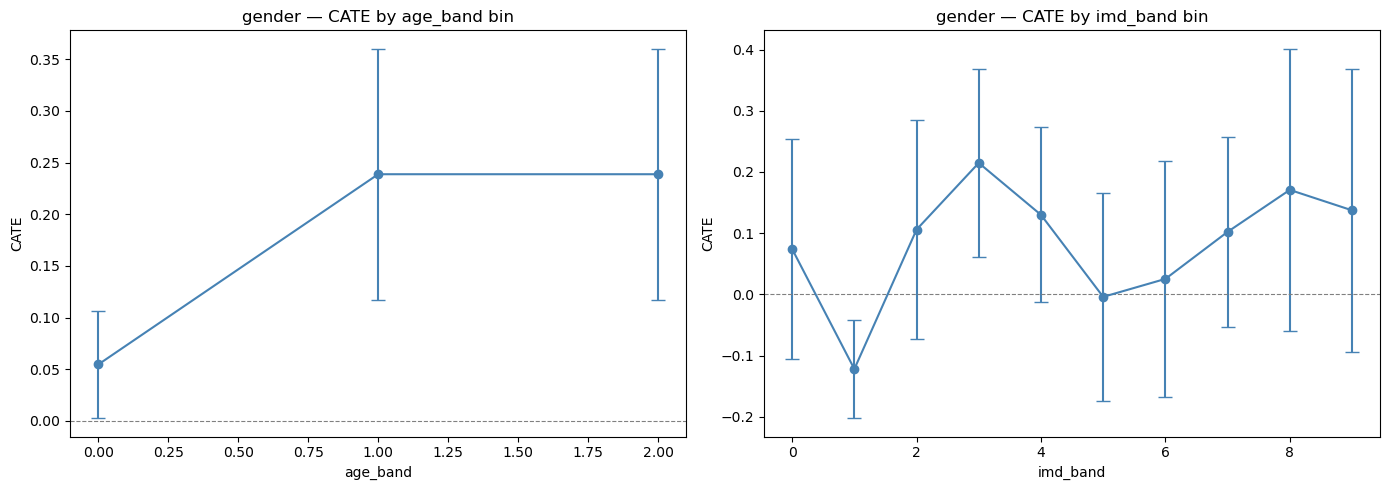

Saved: C:\Users\Disha Sharma\Desktop\Paper_1\RQ2\DDD\DDD_CATE_gender.png


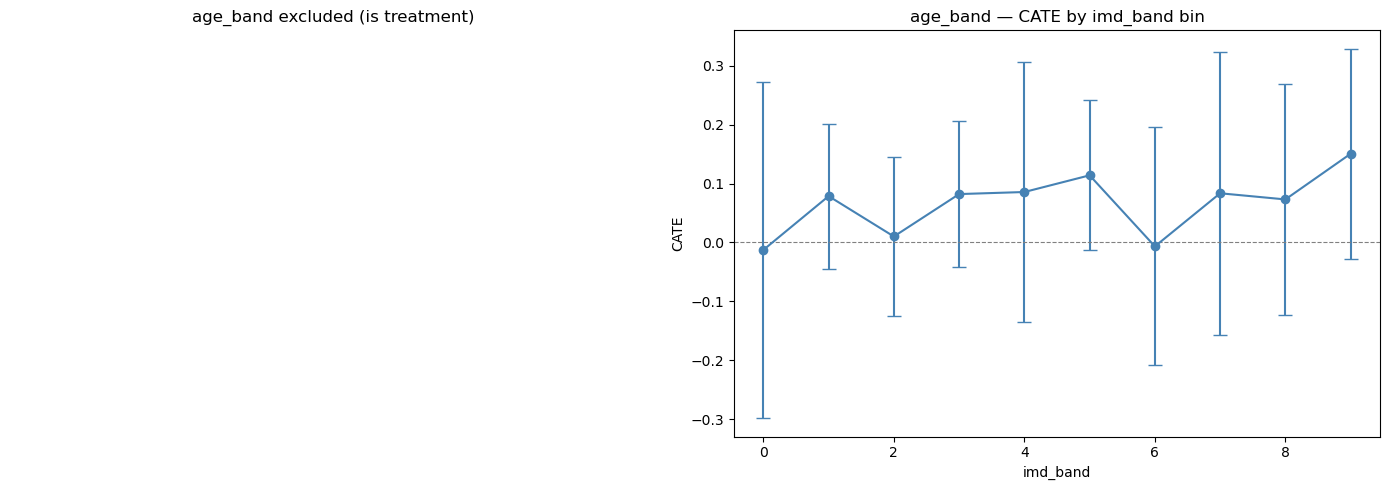

Saved: C:\Users\Disha Sharma\Desktop\Paper_1\RQ2\DDD\DDD_CATE_age_band.png


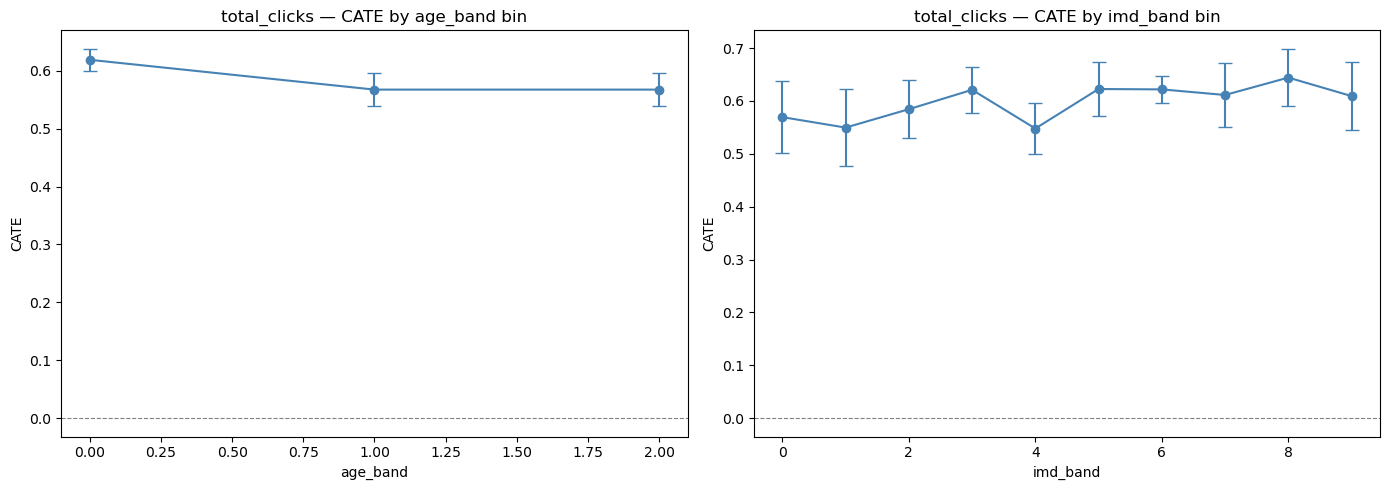

Saved: C:\Users\Disha Sharma\Desktop\Paper_1\RQ2\DDD\DDD_CATE_total_clicks.png


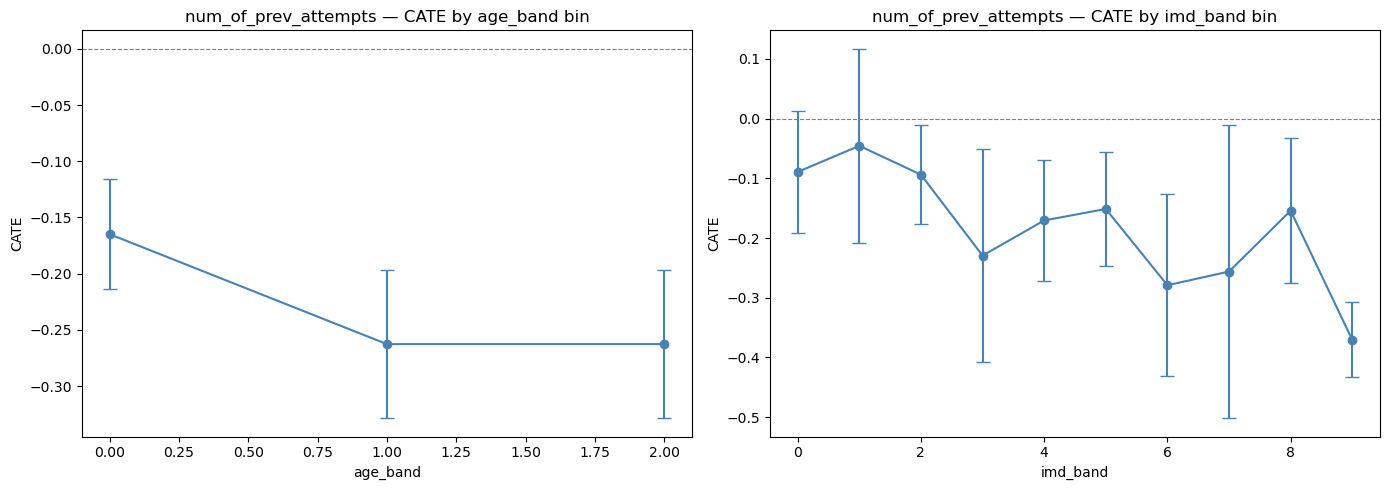

Saved: C:\Users\Disha Sharma\Desktop\Paper_1\RQ2\DDD\DDD_CATE_num_of_prev_attempts.png


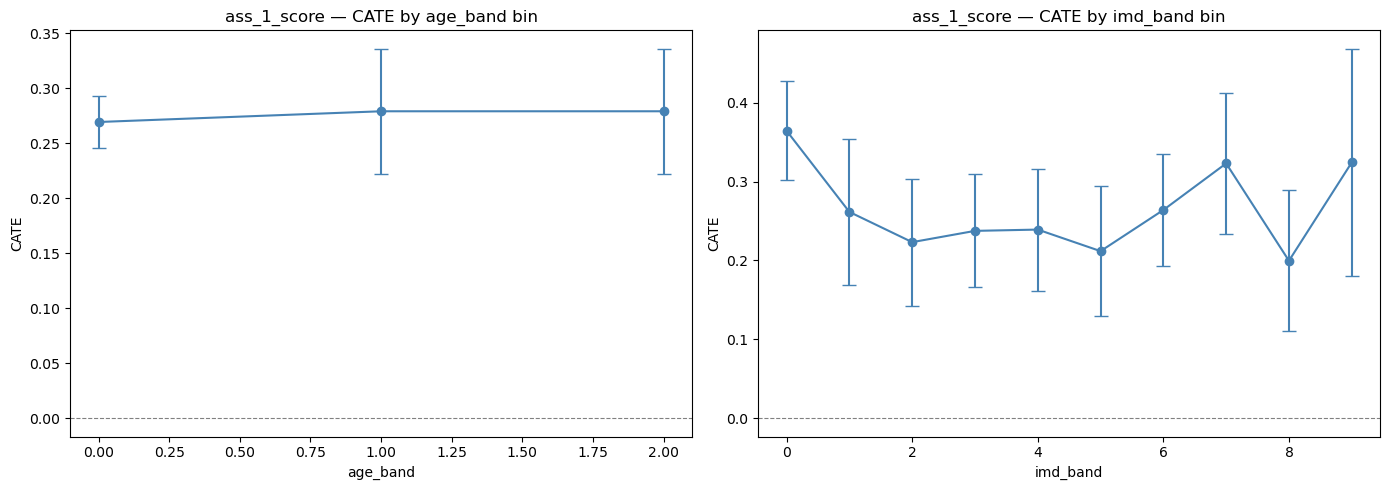

Saved: C:\Users\Disha Sharma\Desktop\Paper_1\RQ2\DDD\DDD_CATE_ass_1_score.png


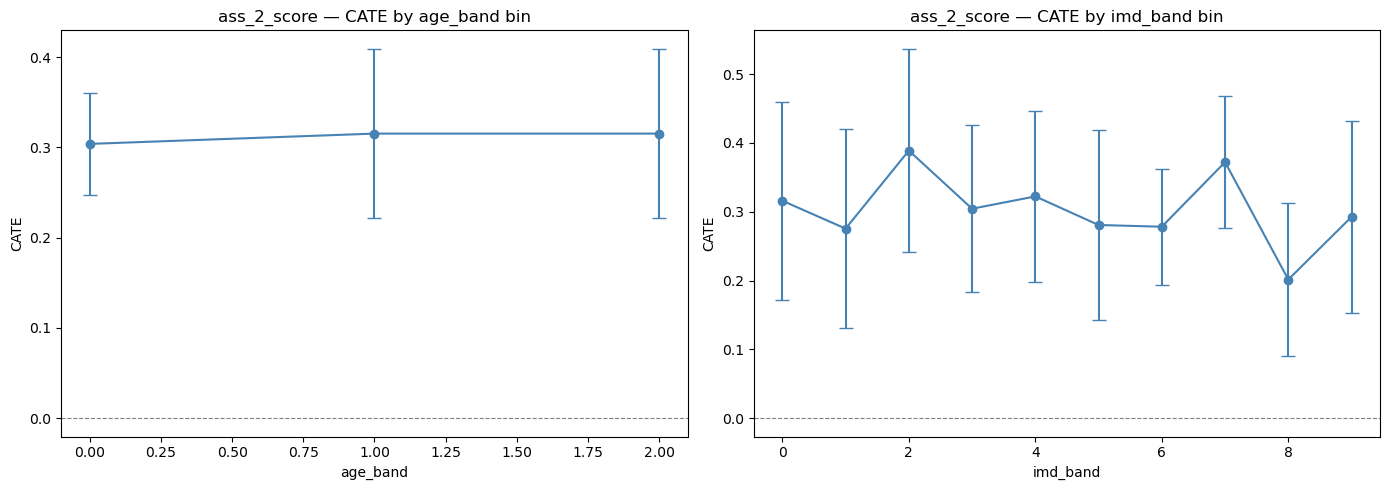

Saved: C:\Users\Disha Sharma\Desktop\Paper_1\RQ2\DDD\DDD_CATE_ass_2_score.png


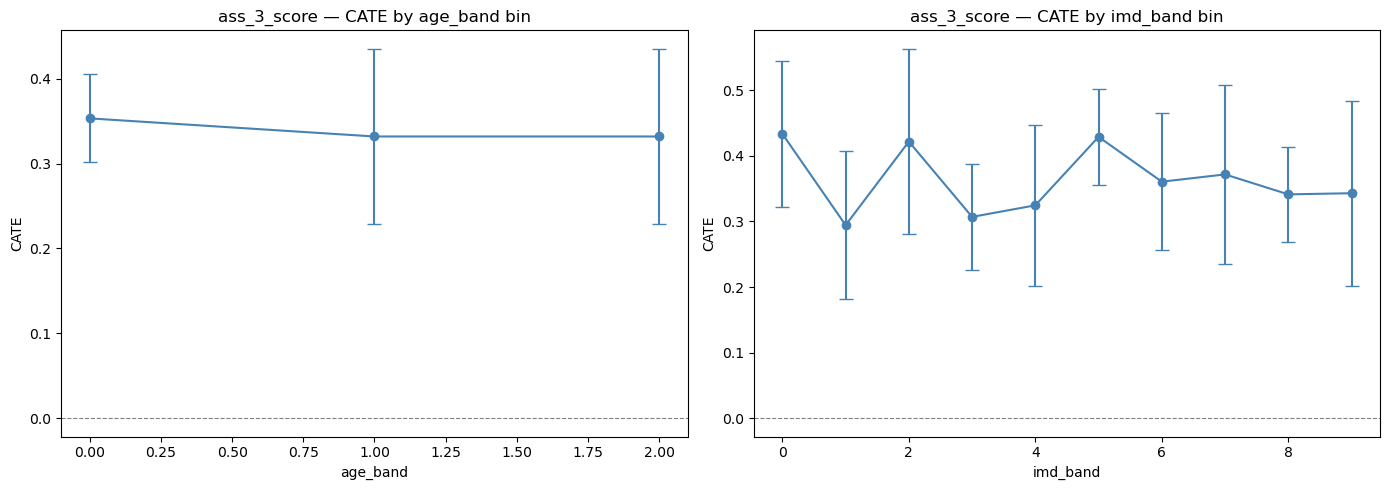

Saved: C:\Users\Disha Sharma\Desktop\Paper_1\RQ2\DDD\DDD_CATE_ass_3_score.png


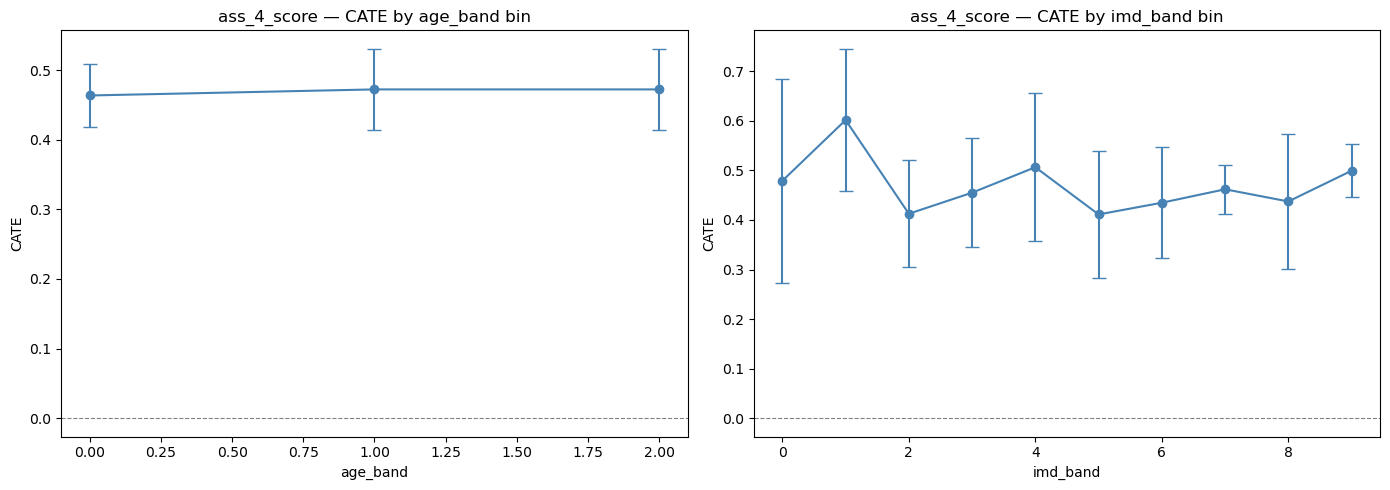

Saved: C:\Users\Disha Sharma\Desktop\Paper_1\RQ2\DDD\DDD_CATE_ass_4_score.png


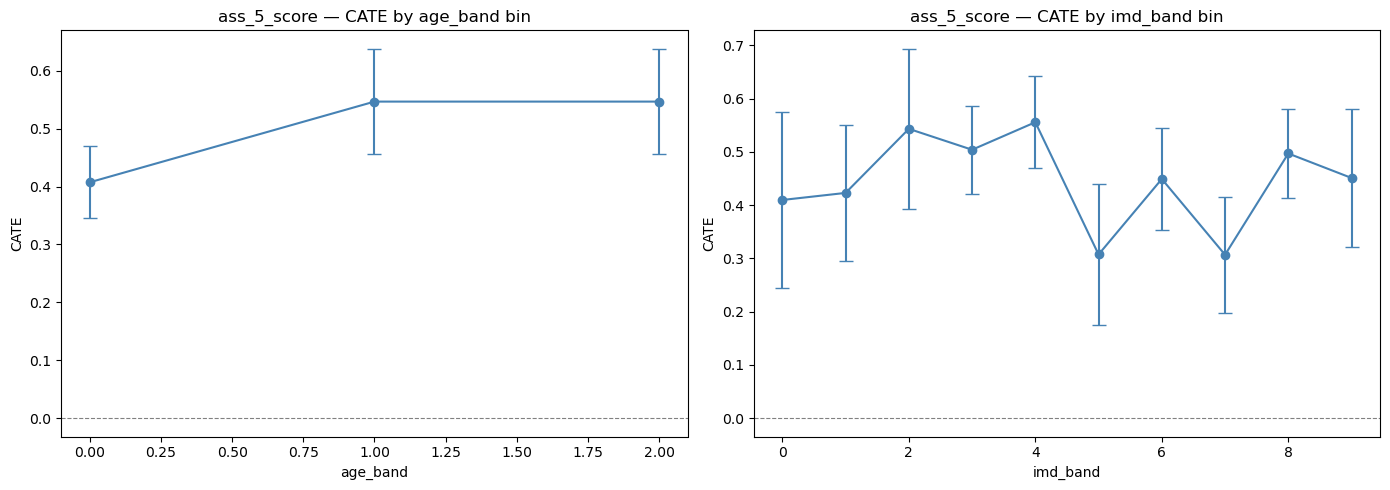

Saved: C:\Users\Disha Sharma\Desktop\Paper_1\RQ2\DDD\DDD_CATE_ass_5_score.png


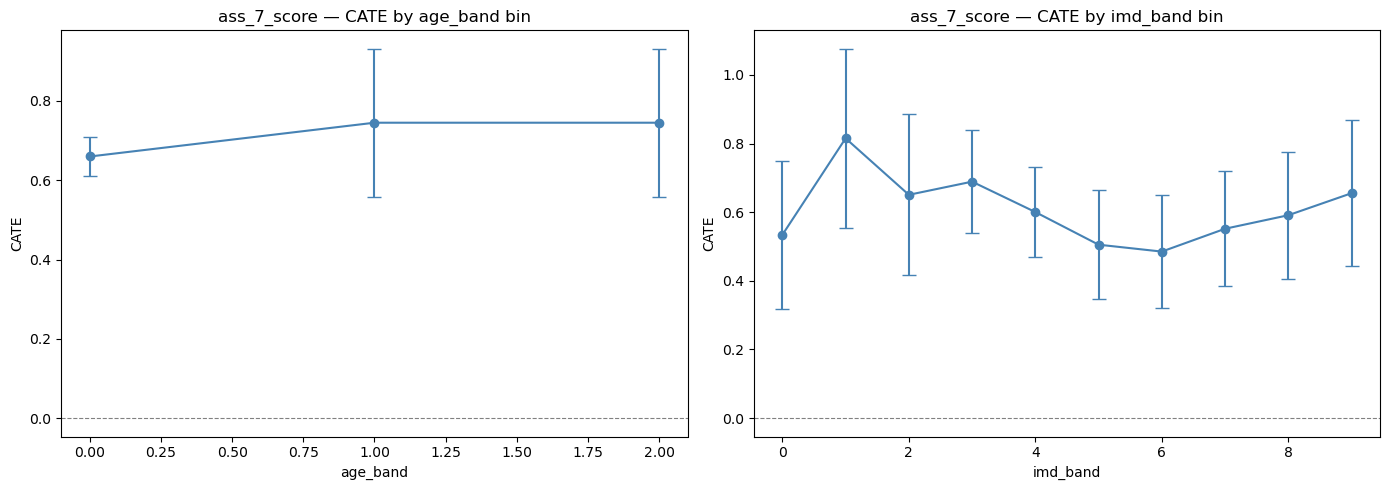

Saved: C:\Users\Disha Sharma\Desktop\Paper_1\RQ2\DDD\DDD_CATE_ass_7_score.png


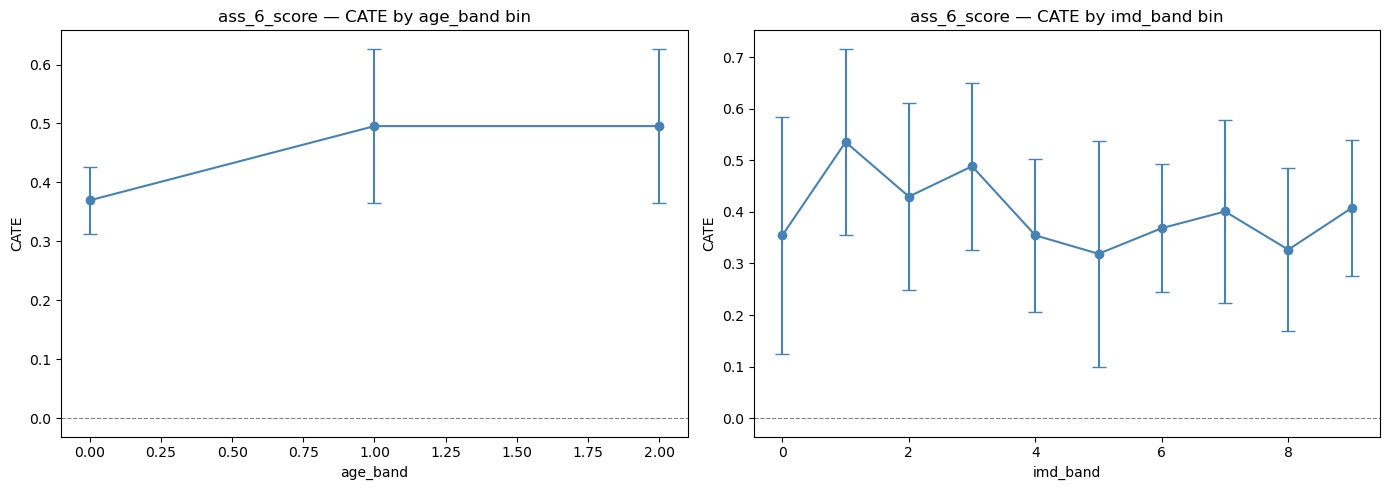

Saved: C:\Users\Disha Sharma\Desktop\Paper_1\RQ2\DDD\DDD_CATE_ass_6_score.png


In [30]:
for treatment in treatments:
    adj_set = adjustment_sets[treatment]

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    for ax, moderator in zip(axes, moderators):
        if treatment == moderator:
            ax.axis('off')
            ax.set_title(f"{moderator} excluded (is treatment)")
            continue

        W_cols = [c for c in adj_set if c != moderator]

        X = df_model[[moderator]].values
        T = df_model[treatment].values
        Y = df_model['final_result'].values
        W = df_model[W_cols].values if len(W_cols) > 0 else None

        est = CausalForestDML(random_state=42)
        est.fit(Y, T, X=X, W=W)

        bin_values = sorted(df_model[moderator].unique())
        X_bins = np.array(bin_values).reshape(-1, 1)

        point_estimates = est.effect(X_bins)
        lb, ub = est.effect_interval(X_bins, alpha=0.05)
        yerr = np.array([point_estimates - lb, ub - point_estimates])

        ax.errorbar(bin_values, point_estimates, yerr=yerr, fmt='o-', capsize=5, color='steelblue')
        ax.set_xlabel(moderator)
        ax.set_ylabel('CATE')
        ax.set_title(f'{treatment} — CATE by {moderator} bin')
        ax.axhline(0, color='gray', linestyle='--', linewidth=0.8)

    plt.tight_layout()
    save_path = os.path.join(OUTPUT_DIR, f"DDD_CATE_{treatment}.png")
    plt.savefig(save_path, dpi=150)
    plt.show()
    plt.close()
    print(f"Saved: {save_path}")

## Policy tree — total_clicks only, both moderators, cost=0 (illustrative)

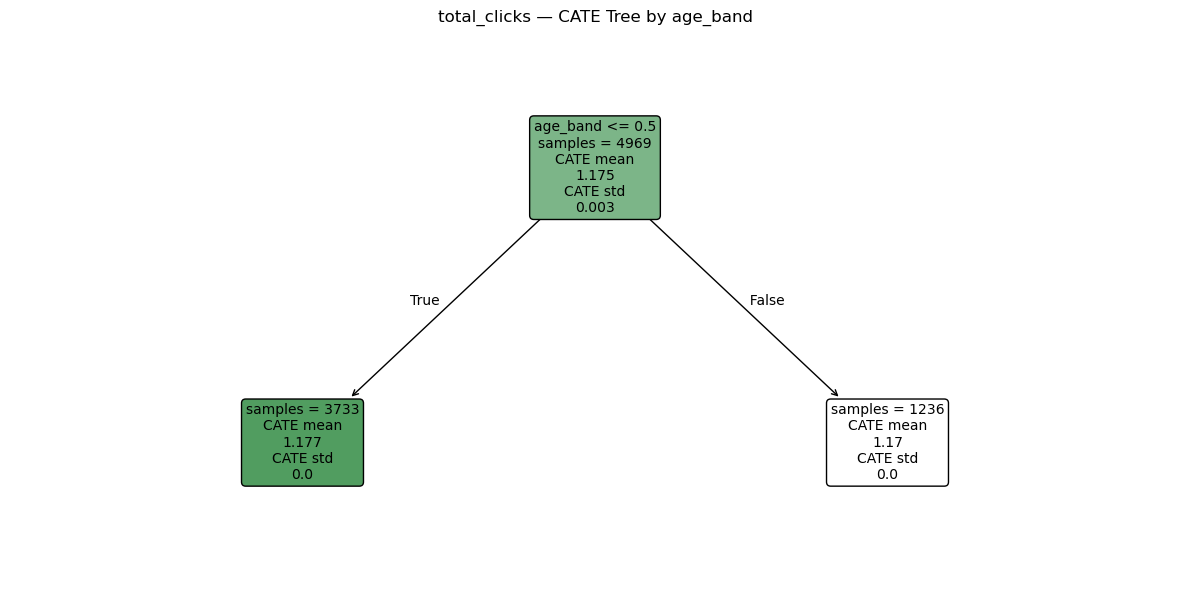

Saved: C:\Users\Disha Sharma\Desktop\Paper_1\RQ2\DDD\DDD_CATEtree_total_clicks_age_band.png


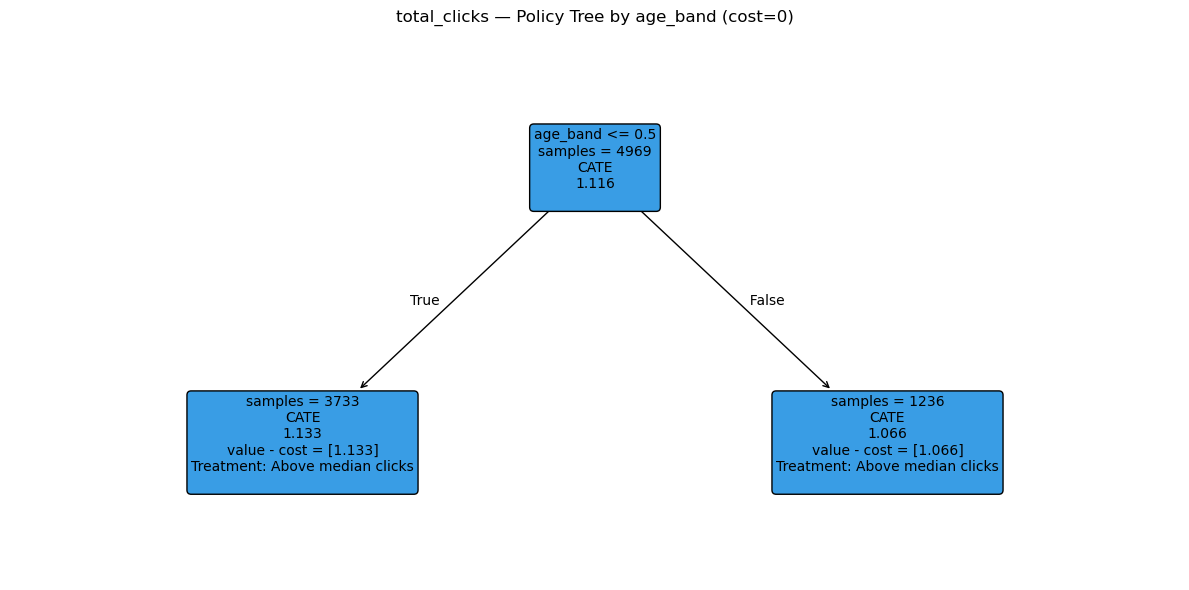

Saved: C:\Users\Disha Sharma\Desktop\Paper_1\RQ2\DDD\DDD_policy_total_clicks_age_band.png


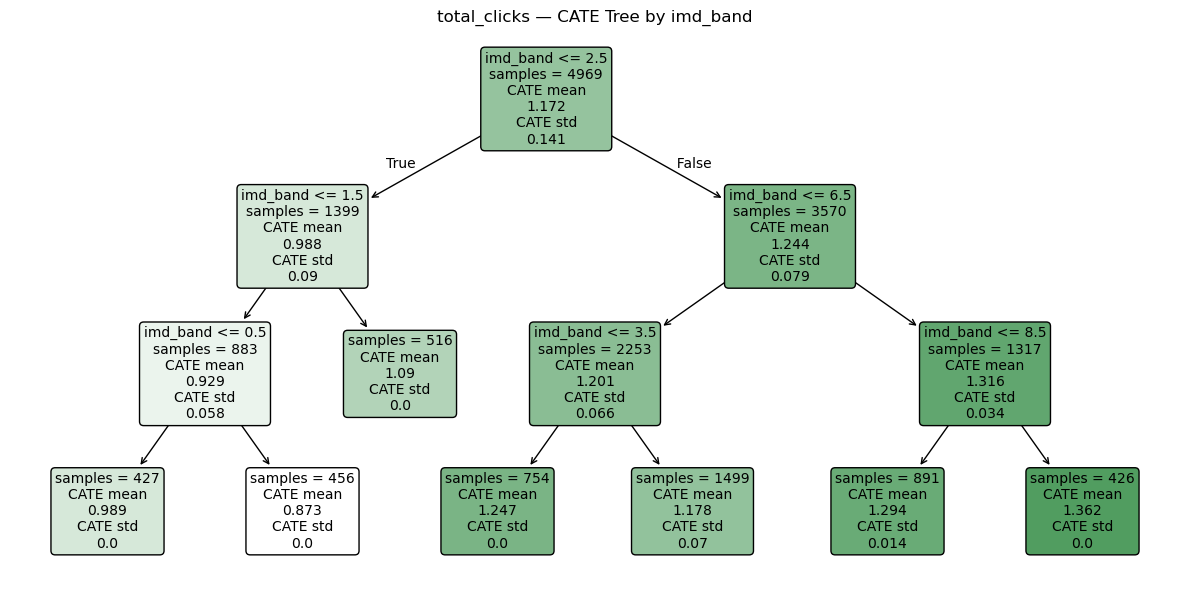

Saved: C:\Users\Disha Sharma\Desktop\Paper_1\RQ2\DDD\DDD_CATEtree_total_clicks_imd_band.png


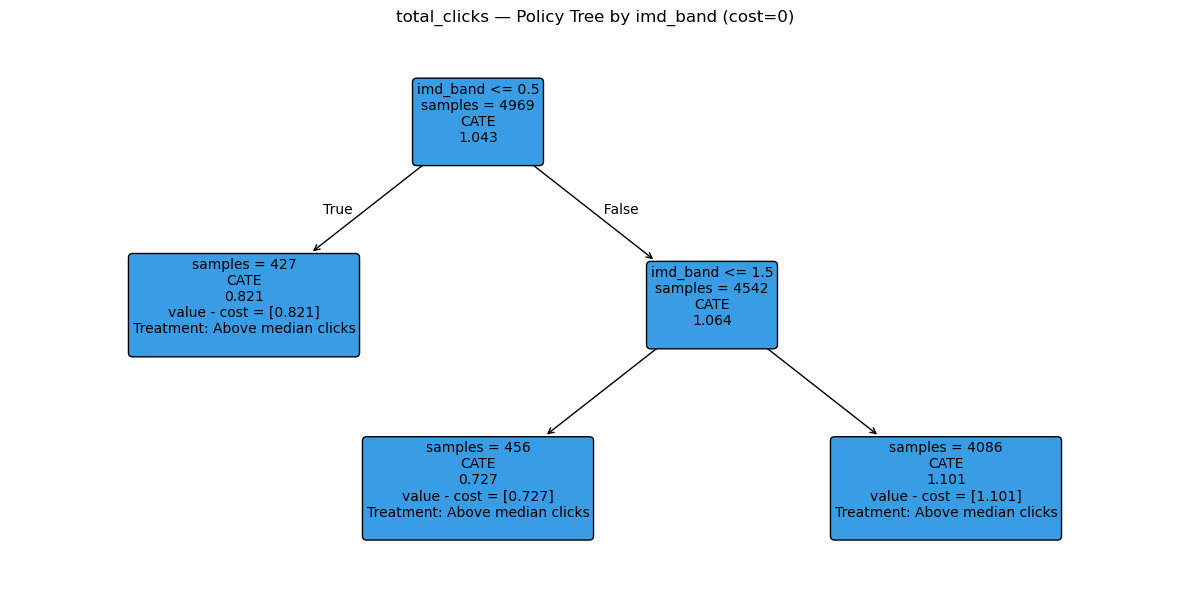

Saved: C:\Users\Disha Sharma\Desktop\Paper_1\RQ2\DDD\DDD_policy_total_clicks_imd_band.png


In [33]:
from econml.cate_interpreter import SingleTreeCateInterpreter, SingleTreePolicyInterpreter

treatment = 'total_clicks'
adj_set = adjustment_sets[treatment]

for moderator in moderators:
    W_cols = [c for c in adj_set if c != moderator]

    X = df_model[[moderator]].values
    T_binary = (df_model[treatment] >= df_model[treatment].median()).astype(int).values
    Y = df_model['final_result'].values
    W = df_model[W_cols].values if len(W_cols) > 0 else None

    est = CausalForestDML(random_state=42)
    est.fit(Y, T_binary, X=X, W=W)

    cate_interpreter = SingleTreeCateInterpreter(include_model_uncertainty=False, max_depth=3)
    cate_interpreter.interpret(est, X)

    plt.figure(figsize=(12, 6))
    cate_interpreter.plot(feature_names=[moderator], fontsize=10)
    plt.title(f'total_clicks — CATE Tree by {moderator}')
    plt.tight_layout()
    save_path = os.path.join(OUTPUT_DIR, f"DDD_CATEtree_total_clicks_{moderator}.png")
    plt.savefig(save_path, dpi=150)
    plt.show()
    plt.close()
    print(f"Saved: {save_path}")

    policy_interpreter = SingleTreePolicyInterpreter(risk_level=0.05, max_depth=3, min_samples_leaf=30)
    policy_interpreter.interpret(est, X, sample_treatment_costs=0)

    plt.figure(figsize=(12, 6))
    policy_interpreter.plot(feature_names=[moderator], treatment_names=['Below median clicks', 'Above median clicks'], fontsize=10)
    plt.title(f'total_clicks — Policy Tree by {moderator} (cost=0)')
    plt.tight_layout()
    save_path = os.path.join(OUTPUT_DIR, f"DDD_policy_total_clicks_{moderator}.png")
    plt.savefig(save_path, dpi=150)
    plt.show()
    plt.close()
    print(f"Saved: {save_path}")

## ATE heatmap

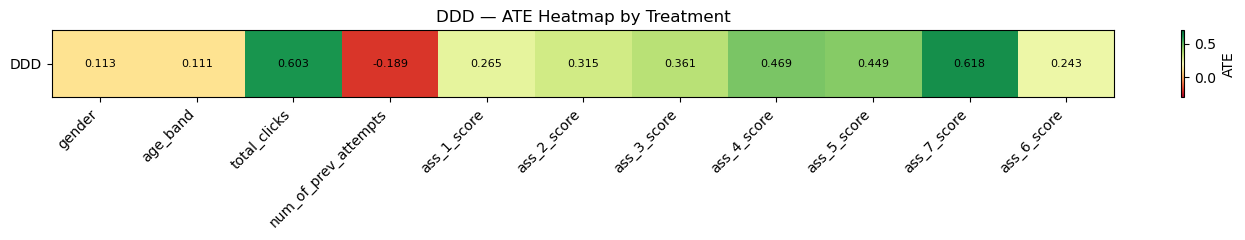

Saved: C:\Users\Disha Sharma\Desktop\Paper_1\RQ2\DDD\DDD_ATE_heatmap.png


In [36]:
heatmap_data = results_df.set_index('treatment')[['ATE']].T

plt.figure(figsize=(14, 2.5))
plt.imshow(heatmap_data.values, cmap='RdYlGn', aspect='auto', vmin=-0.3, vmax=0.7)
plt.xticks(range(len(heatmap_data.columns)), heatmap_data.columns, rotation=45, ha='right')
plt.yticks([0], ['DDD'])
plt.colorbar(label='ATE')

for i, val in enumerate(heatmap_data.values[0]):
    plt.text(i, 0, f'{val:.3f}', ha='center', va='center', fontsize=8)

plt.title('DDD — ATE Heatmap by Treatment')
plt.tight_layout()
save_path = os.path.join(OUTPUT_DIR, "DDD_ATE_heatmap.png")
plt.savefig(save_path, dpi=150)
plt.show()
plt.close()
print(f"Saved: {save_path}")

## DAG with ATE node overlay — manual fixed-position layout

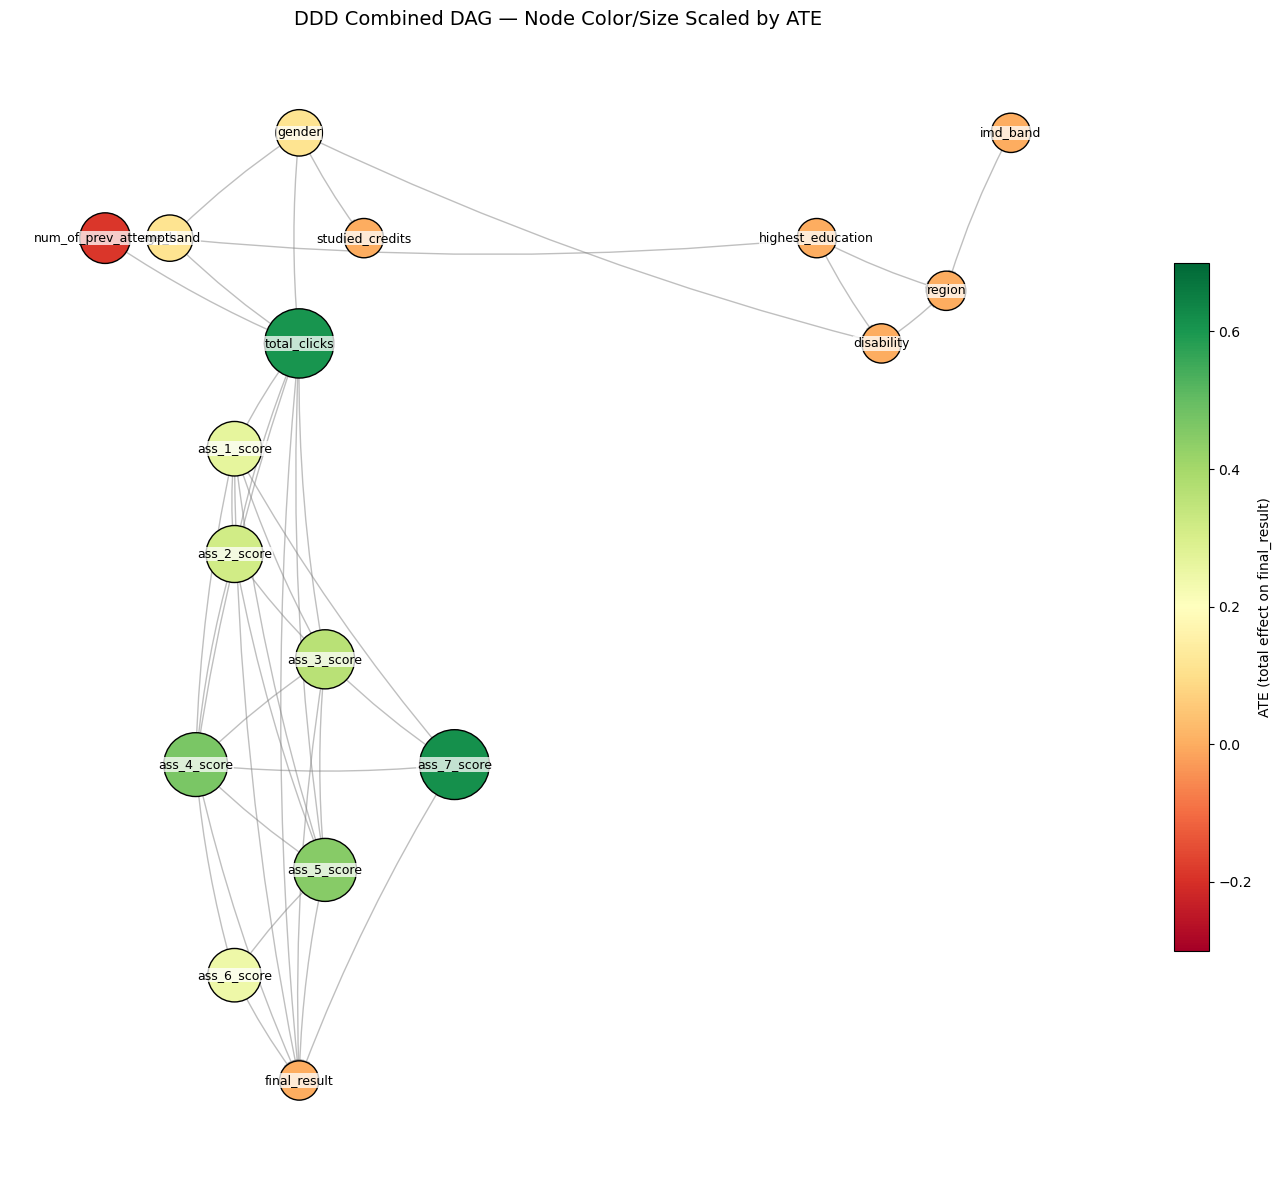

Saved: C:\Users\Disha Sharma\Desktop\Paper_1\RQ2\DDD\DDD_DAG_with_ATE.png


In [39]:
pos = {
    'gender': (2, 7),
    'highest_education': (6, 6),
    'imd_band': (7.5, 7),
    'disability': (6.5, 5),
    'age_band': (1, 6),
    'region': (7, 5.5),
    'studied_credits': (2.5, 6),
    'total_clicks': (2, 5),
    'num_of_prev_attempts': (0.5, 6),
    'ass_1_score': (1.5, 4),
    'ass_2_score': (1.5, 3),
    'ass_3_score': (2.2, 2),
    'ass_4_score': (1.2, 1),
    'ass_5_score': (2.2, 0),
    'ass_7_score': (3.2, 1),
    'ass_6_score': (1.5, -1),
    'final_result': (2, -2),
}

ate_lookup = results_df.set_index('treatment')['ATE'].to_dict()

fig, ax = plt.subplots(figsize=(14, 12))

node_colors, node_sizes = [], []
for node in G.nodes():
    ate_val = ate_lookup.get(node, 0)
    node_colors.append(ate_val)
    node_sizes.append(800 + abs(ate_val) * 2800)

missing_pos = [n for n in G.nodes() if n not in pos]
if missing_pos:
    print("WARNING — missing pos for:", missing_pos)

nx.draw_networkx_edges(G, pos, ax=ax, edge_color='gray', arrows=True, arrowsize=12, alpha=0.5, connectionstyle='arc3,rad=0.05')
nc = nx.draw_networkx_nodes(G, pos, ax=ax, node_color=node_colors, node_size=node_sizes,
                             cmap='RdYlGn', vmin=-0.3, vmax=0.7, edgecolors='black')
nx.draw_networkx_labels(G, pos, ax=ax, font_size=9,
                         bbox=dict(facecolor='white', edgecolor='none', alpha=0.75, pad=0.5))

cbar = plt.colorbar(nc, ax=ax, shrink=0.6)
cbar.set_label('ATE (total effect on final_result)')

ax.set_title('DDD Combined DAG — Node Color/Size Scaled by ATE', fontsize=14)
ax.axis('off')
plt.tight_layout()
save_path = os.path.join(OUTPUT_DIR, "DDD_DAG_with_ATE.png")
plt.savefig(save_path, dpi=150)
plt.show()
plt.close()
print(f"Saved: {save_path}")